# NEU Surface Defect Dataset — EDA
Explore class distribution, image properties, and visualize samples before training.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

## 1. Dataset Paths

In [2]:
TRAIN_DIR = "../dataset/NEU-DET/train/images"
VAL_DIR   = "../dataset/NEU-DET/validation/images"

# Class names are the subfolder names
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
print("Classes:", CLASS_NAMES)
print("Num classes:", len(CLASS_NAMES))

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Num classes: 6


## 2. Class Distribution

In [3]:
def count_images(root_dir):
    counts = {}
    for cls in sorted(os.listdir(root_dir)):
        cls_path = os.path.join(root_dir, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
            ])
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)

print("Train counts:")
for cls, count in train_counts.items():
    print(f"  {cls}: {count}")

print("\nValidation counts:")
for cls, count in val_counts.items():
    print(f"  {cls}: {count}")

print(f"\nTotal train: {sum(train_counts.values())}")
print(f"Total val:   {sum(val_counts.values())}")

Train counts:
  crazing: 240
  inclusion: 240
  patches: 240
  pitted_surface: 240
  rolled-in_scale: 240
  scratches: 240

Validation counts:
  crazing: 60
  inclusion: 60
  patches: 60
  pitted_surface: 60
  rolled-in_scale: 60
  scratches: 60

Total train: 1440
Total val:   360


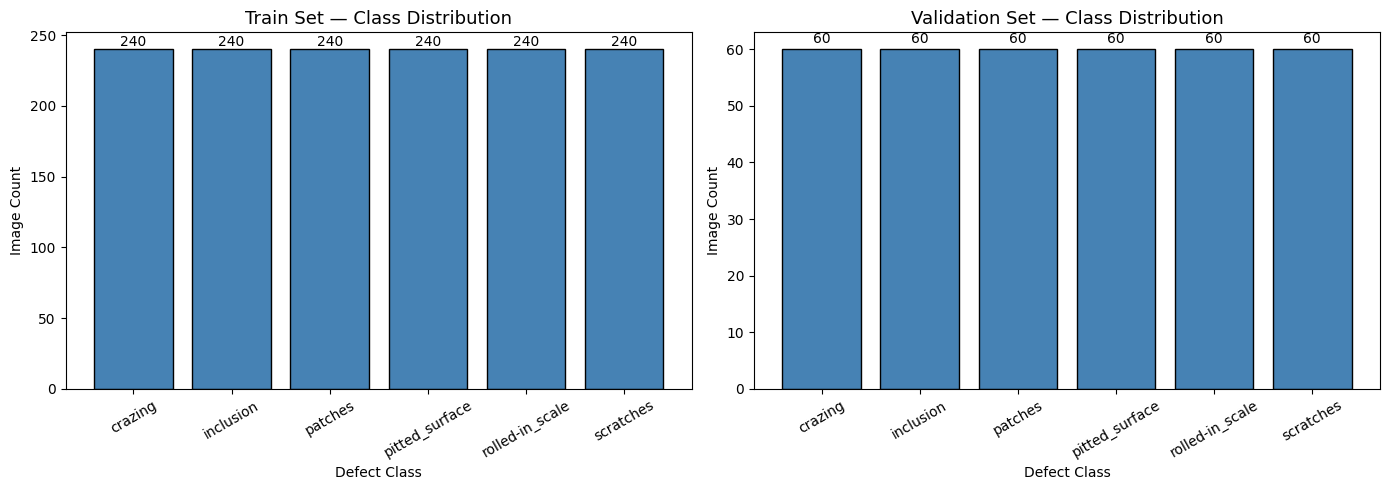

In [4]:
# Bar chart — class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in zip(axes, [train_counts, val_counts], ["Train", "Validation"]):
    bars = ax.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='black')
    ax.set_title(f"{title} Set — Class Distribution", fontsize=13)
    ax.set_xlabel("Defect Class")
    ax.set_ylabel("Image Count")
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=10
        )

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

## 3. Sample Images Per Class

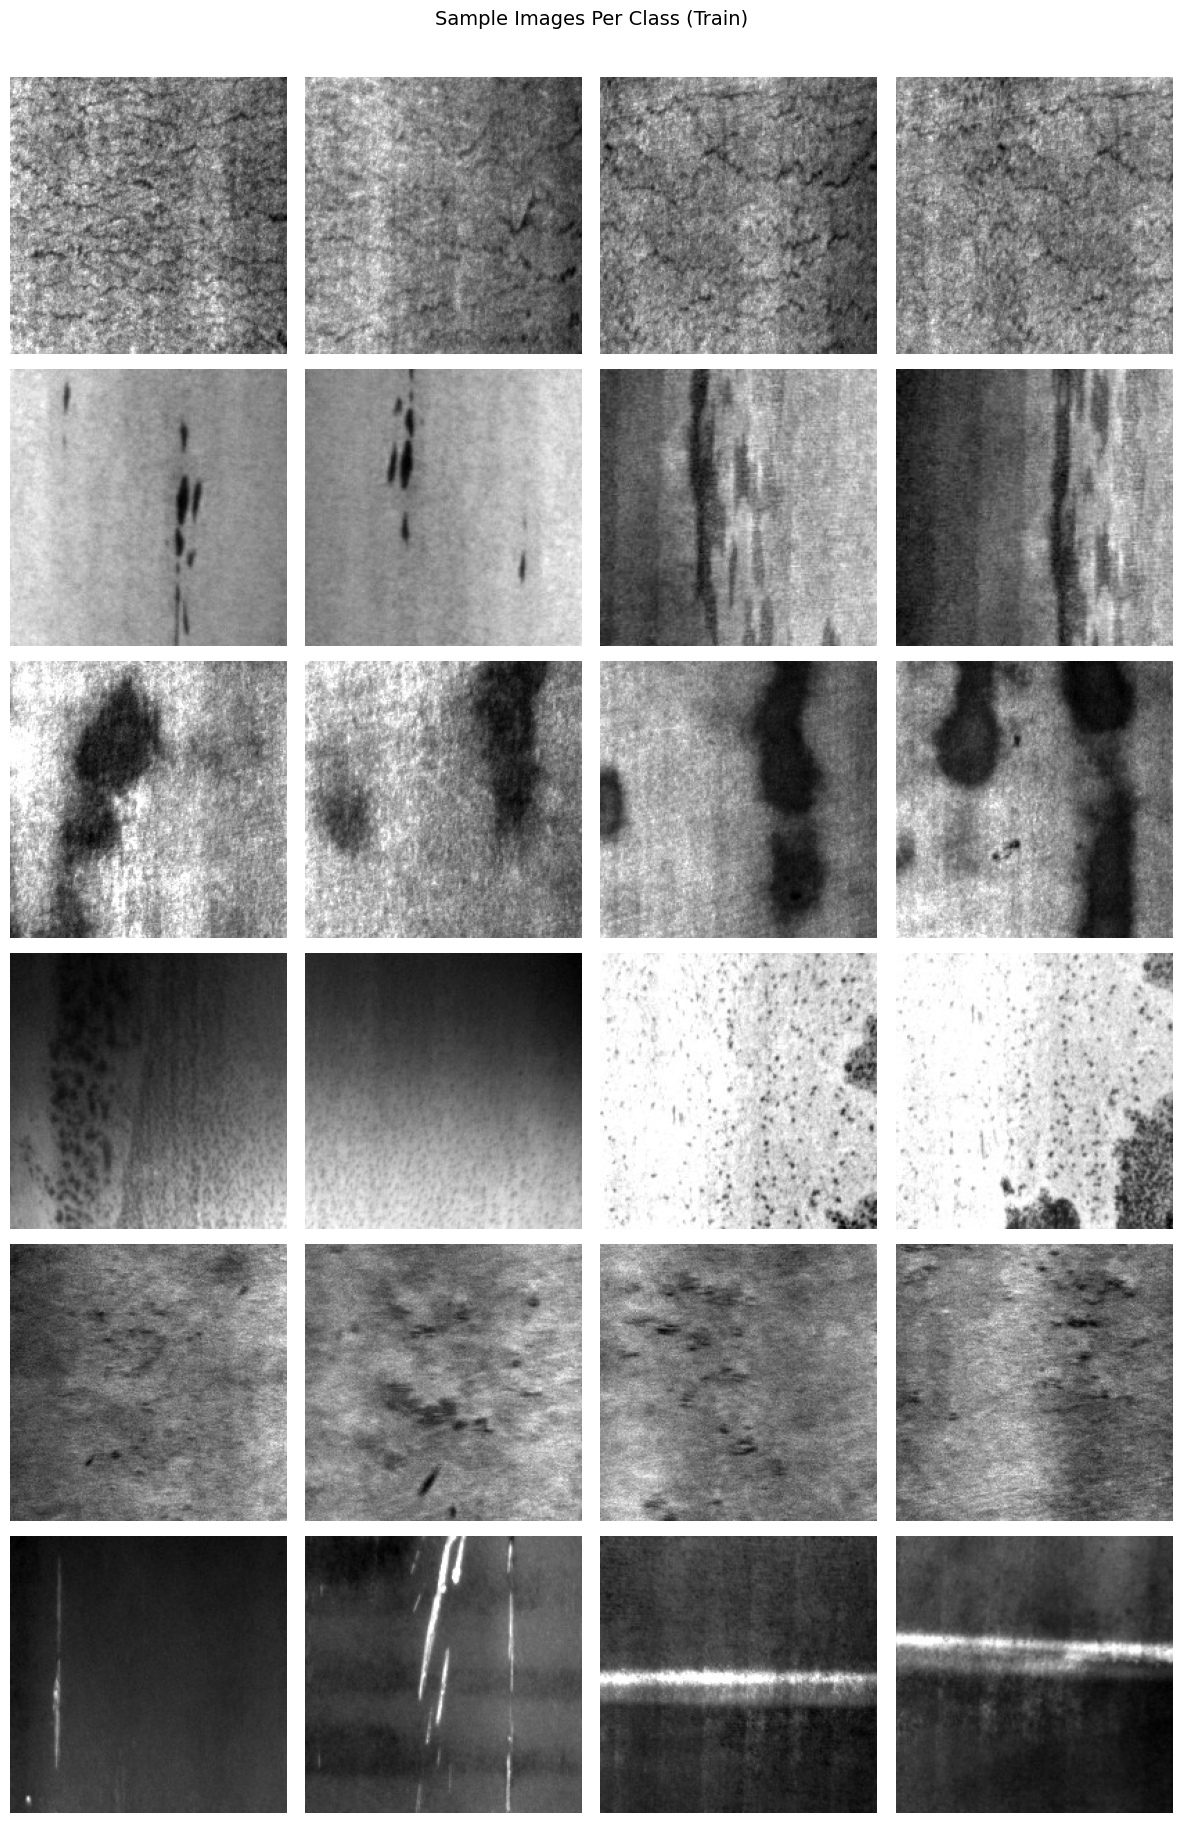

In [5]:
def show_samples(root_dir, n_per_class=4):
    classes = sorted(os.listdir(root_dir))
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 3, len(classes) * 3))

    for row, cls in enumerate(classes):
        cls_path = os.path.join(root_dir, cls)
        images = [
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
        ]
        samples = images[:n_per_class]

        for col, img_name in enumerate(samples):
            img = Image.open(os.path.join(cls_path, img_name)).convert("L")  # grayscale
            axes[row][col].imshow(img, cmap='gray')
            axes[row][col].axis('off')
            if col == 0:
                axes[row][col].set_ylabel(cls, fontsize=11, rotation=0, labelpad=60, va='center')

    plt.suptitle("Sample Images Per Class (Train)", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
    plt.show()

show_samples(TRAIN_DIR, n_per_class=4)

## 4. Image Properties — Size and Channel Check

In [6]:
sizes = []
modes = defaultdict(int)  # e.g. 'L' = grayscale, 'RGB' = color

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            img = Image.open(os.path.join(cls_path, fname))
            sizes.append(img.size)  # (width, height)
            modes[img.mode] += 1

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Unique sizes: {set(sizes)}")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")
print(f"\nImage modes (channel types): {dict(modes)}")
print("  L = grayscale, RGB = color")

Unique sizes: {(200, 200)}
Width  — min: 200, max: 200, mean: 200.0
Height — min: 200, max: 200, mean: 200.0

Image modes (channel types): {'RGB': 1440}
  L = grayscale, RGB = color


## 5. Pixel Intensity Distribution Per Class

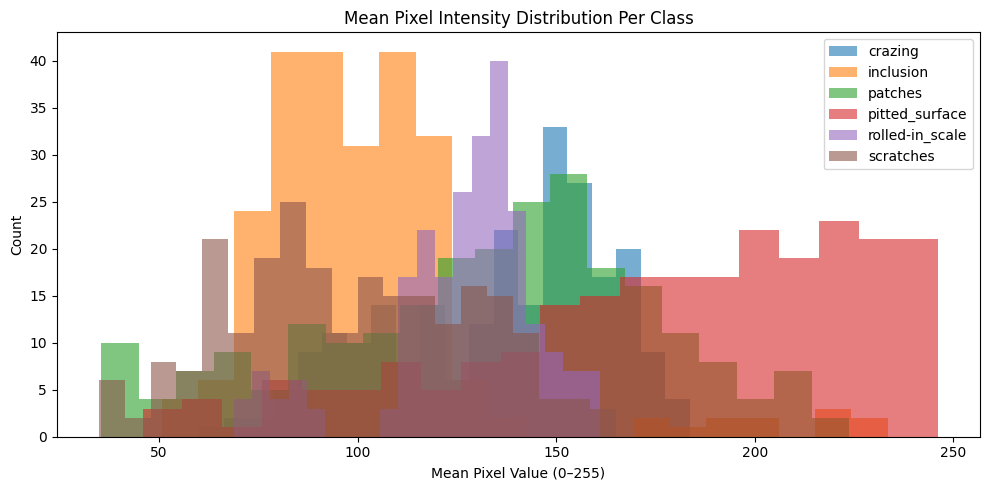

In [7]:
# Mean pixel intensity per class — tells us if any class looks visually distinct
fig, ax = plt.subplots(figsize=(10, 5))

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    pixel_means = []
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            img = np.array(Image.open(os.path.join(cls_path, fname)).convert("L"))
            pixel_means.append(img.mean())
    ax.hist(pixel_means, bins=20, alpha=0.6, label=cls)

ax.set_title("Mean Pixel Intensity Distribution Per Class")
ax.set_xlabel("Mean Pixel Value (0–255)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("pixel_intensity.png", dpi=150)
plt.show()

## 6. Dataset Mean and Std — For Normalization in Training

In [8]:
# Compute mean and std across all training images
# These values go into transforms.Normalize() in train.py

pixel_values = []

for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            img = np.array(Image.open(os.path.join(cls_path, fname)).convert("RGB")) / 255.0
            pixel_values.append(img)

all_pixels = np.concatenate([p.reshape(-1, 3) for p in pixel_values], axis=0)

mean = all_pixels.mean(axis=0)
std  = all_pixels.std(axis=0)

print("Dataset mean (R, G, B):", mean.round(4))
print("Dataset std  (R, G, B):", std.round(4))
print()
print("Use these in train.py:")
print(f"  transforms.Normalize(mean={list(mean.round(4))}, std={list(std.round(4))})")
print()
print("Note: if mean R=G=B and std R=G=B, images are effectively grayscale")
print("ResNet18 still expects 3 channels — convert L -> RGB in your Dataset class")

Dataset mean (R, G, B): [0.505 0.505 0.505]
Dataset std  (R, G, B): [0.2083 0.2083 0.2083]

Use these in train.py:
  transforms.Normalize(mean=[np.float64(0.505), np.float64(0.505), np.float64(0.505)], std=[np.float64(0.2083), np.float64(0.2083), np.float64(0.2083)])

Note: if mean R=G=B and std R=G=B, images are effectively grayscale
ResNet18 still expects 3 channels — convert L -> RGB in your Dataset class


## 7. Summary

After running all cells, note down:
- Are classes balanced? If one class has far fewer images, you may need weighted sampling in train.py
- Are all images the same size? If yes, no resizing surprise during loading
- What is the image mode? NEU images are grayscale (L) — convert to RGB for ResNet18
- Copy the mean/std values from Cell 6 into your train.py Normalize transform